# Questão 3

Nesta questão, a imagem [sosias.jpg](sosias.jpg) é convertida para tons de cinza e analisada no domínio da DCT bidimensional.
O objetivo é visualizar como a energia fica concentrada em baixas frequências espaciais.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy.fft import dct, idct, fft, ifft, dctn, idctn
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'sosias.jpg').exists():
    PRACTICE_DIR = CWD
elif (CWD / 'pratica_4' / 'sosias.jpg').exists():
    PRACTICE_DIR = (CWD / 'pratica_4').resolve()
else:
    PRACTICE_DIR = CWD

DATA_DIR = (PRACTICE_DIR.parent / 'data').resolve()
AUDIO_PATH = DATA_DIR / 'handel.wav'
IMAGE_PATH = (PRACTICE_DIR / 'sosias.jpg').resolve()


In [2]:
def to_float_mono(signal):
    signal = np.asarray(signal)
    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    return signal


def show_audio(signal, fs, label):
    signal = np.asarray(signal, dtype=np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    display(Audio(signal, rate=fs))
    print(label)


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def select_by_energy(coeffs, keep_energy):
    coeffs = np.asarray(coeffs)
    energy = np.abs(coeffs) ** 2
    flat_energy = energy.ravel()
    order = np.argsort(flat_energy)[::-1]
    cumulative = np.cumsum(flat_energy[order])
    total_energy = cumulative[-1]
    threshold = keep_energy * total_energy
    keep_count = int(np.searchsorted(cumulative, threshold, side='left')) + 1

    mask = np.zeros(coeffs.size, dtype=bool)
    mask[order[:keep_count]] = True
    mask = mask.reshape(coeffs.shape)

    compressed = np.zeros_like(coeffs)
    compressed[mask] = coeffs[mask]
    retained = float(np.sum(np.abs(compressed) ** 2) / total_energy)
    return compressed, keep_count, retained, mask


def compress_audio_dct(signal, keep_energy):
    coeffs = dct(signal, norm='ortho')
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = idct(compressed, norm='ortho')
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def compress_audio_fft(signal, keep_energy):
    coeffs = fft(signal)
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = np.real(ifft(compressed))
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def plot_time_and_error(original, reconstructed, fs, title):
    t = np.arange(len(original)) / fs
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(t, original, label='Original', alpha=0.8)
    axes[0].plot(t, reconstructed, label='Reconstruido', alpha=0.7)
    axes[0].set_title(title)
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()

    axes[1].plot(t, original - reconstructed, color='tab:red')
    axes[1].set_title('Erro de reconstrução')
    axes[1].set_xlabel('Tempo (s)')
    axes[1].set_ylabel('Erro')
    plt.tight_layout()
    plt.show()
def load_gray_image(path):
    image = Image.open(path).convert('L')
    array = np.asarray(image, dtype=np.float64) / 255.0
    return image, array


def compress_image_dct(image_array, keep_energy):
    coeffs = dctn(image_array, norm='ortho')
    compressed, keep_count, retained, mask = select_by_energy(coeffs, keep_energy)
    reconstructed = idctn(compressed, norm='ortho')
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
        'mask': mask,
    }


def blockwise_dct_compression(image_array, block_size, keep_energy):
    h, w = image_array.shape
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    padded = np.pad(image_array, ((0, pad_h), (0, pad_w)), mode='edge')
    reconstructed = np.zeros_like(padded)
    total_kept = 0
    total_coeffs = padded.size

    for i in range(0, padded.shape[0], block_size):
        for j in range(0, padded.shape[1], block_size):
            block = padded[i:i + block_size, j:j + block_size]
            coeffs = dctn(block, norm='ortho')
            compressed, keep_count, _, _ = select_by_energy(coeffs, keep_energy)
            reconstructed[i:i + block_size, j:j + block_size] = idctn(compressed, norm='ortho')
            total_kept += keep_count

    reconstructed = reconstructed[:h, :w]
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return {
        'reconstructed': reconstructed,
        'keep_count': total_kept,
        'compression_ratio': total_kept / total_coeffs,
    }


In [3]:
image_pil, image = load_gray_image(IMAGE_PATH)
coeffs = dctn(image, norm='ortho')
energy = coeffs ** 2
cumulative = np.cumsum(np.sort(energy.ravel())[::-1]) / np.sum(energy)

print(f'Dimensoes da imagem: {image.shape[1]} x {image.shape[0]}')
print(f'Numero total de coeficientes: {image.size}')


Dimensoes da imagem: 1200 x 670
Numero total de coeficientes: 804000


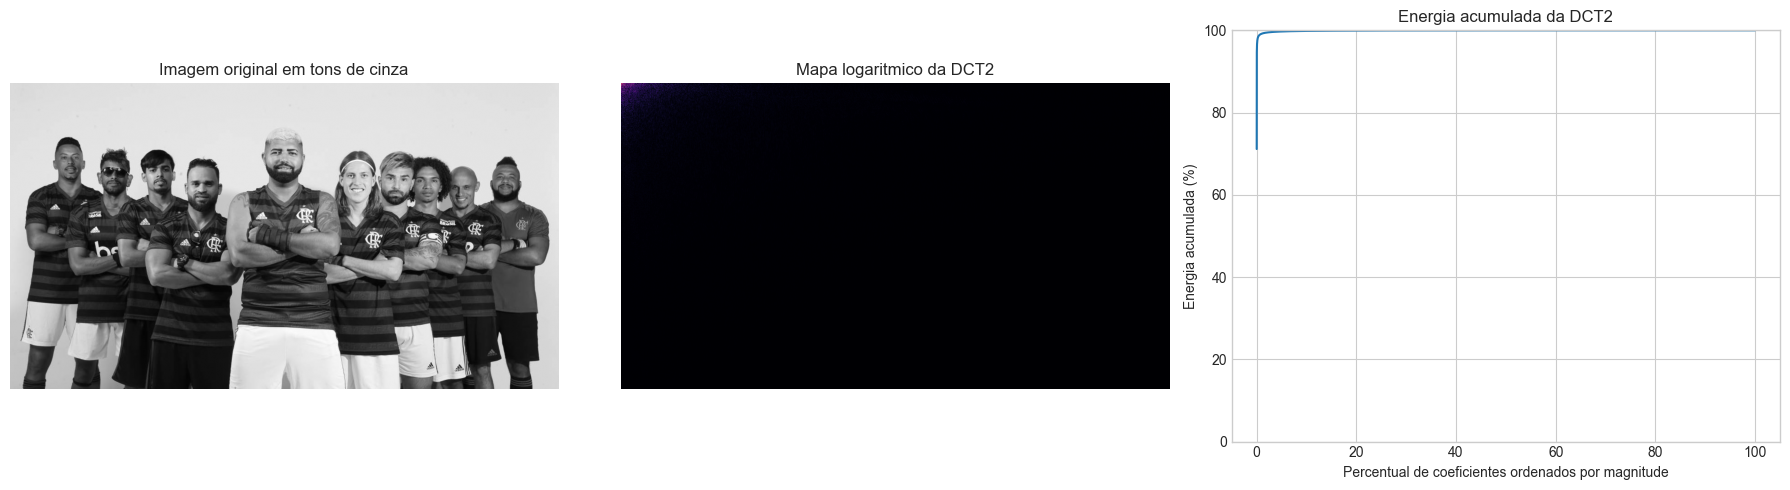

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Imagem original em tons de cinza')
axes[0].axis('off')

axes[1].imshow(np.log1p(np.abs(coeffs)), cmap='magma')
axes[1].set_title('Mapa logaritmico da DCT2')
axes[1].axis('off')

axes[2].plot(np.linspace(0, 100, len(cumulative)), cumulative * 100)
axes[2].set_title('Energia acumulada da DCT2')
axes[2].set_xlabel('Percentual de coeficientes ordenados por magnitude')
axes[2].set_ylabel('Energia acumulada (%)')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()


## Comentários

- A maior parte da energia aparece concentrada na região superior esquerda do mapa da DCT2, associada às baixas frequências espaciais.
- Isso indica que a imagem é fortemente correlacionada no espaço e pode ser comprimida mantendo apenas parte dos coeficientes.
- A curva de energia acumulada evidencia que poucos coeficientes já representam boa parte do conteúdo visual relevante.
